Saved full correlation matrix to ../../results/Correlation_Results/correlation_matrix_all.csv
Saved top correlations table to ../../results/Correlation_Results/top_correlations.csv
Saved representative correlation matrix to ../../results/Correlation_Results/representative_correlation_matrix.csv

Cryptocurrency Correlation Analysis for Representative Coins

--- BETH-USD ---
Top 4 Positive Correlations:
  ETH-USD: 0.996
  STETH-USD: 0.996
  WETH-USD: 0.991
  ETC-USD: 0.825
Top 4 Negative Correlations:
  FTN-USD: 0.091
  DAI-USD: 0.111
  LEO-USD: 0.209
  SUN-USD: 0.304

--- BTC-USD ---
Top 4 Positive Correlations:
  BETH-USD: 0.808
  ETH-USD: 0.807
  DOGE-USD: 0.806
  STETH-USD: 0.802
Top 4 Negative Correlations:
  FTN-USD: 0.144
  DAI-USD: 0.204
  SUN-USD: 0.264
  TRX-USD: 0.298

--- ADA-USD ---
Top 4 Positive Correlations:
  XRP-USD: 0.710
  LINK-USD: 0.695
  DOT-USD: 0.675
  SOL-USD: 0.673
Top 4 Negative Correlations:
  FTN-USD: 0.059
  DAI-USD: 0.105
  LEO-USD: 0.134
  TRX-USD: 0.272


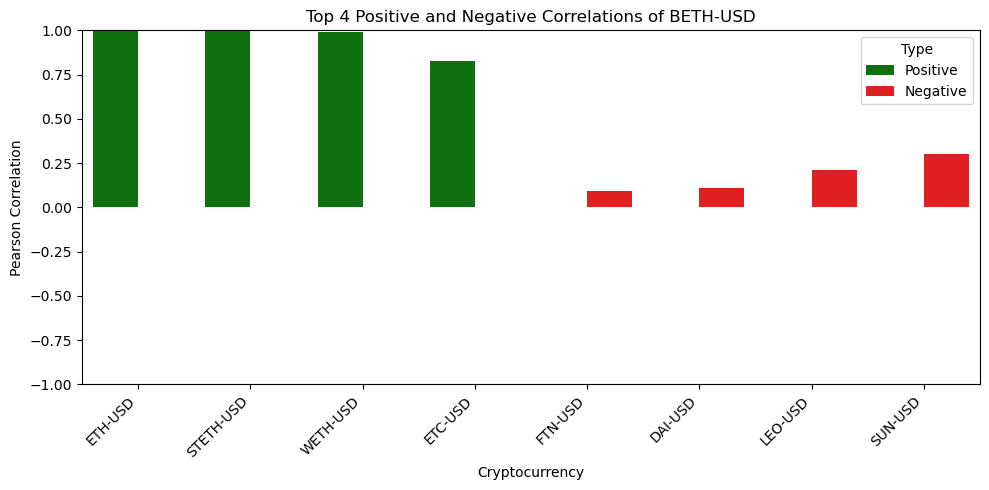

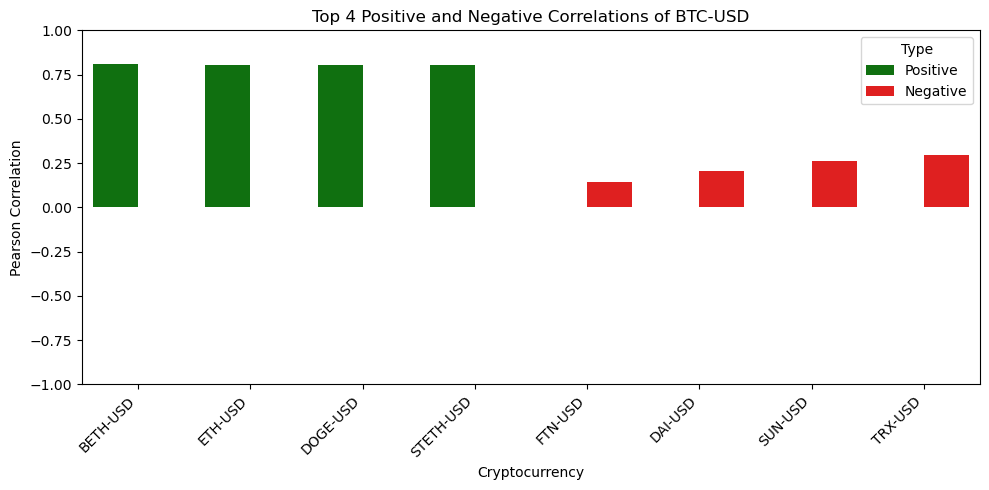

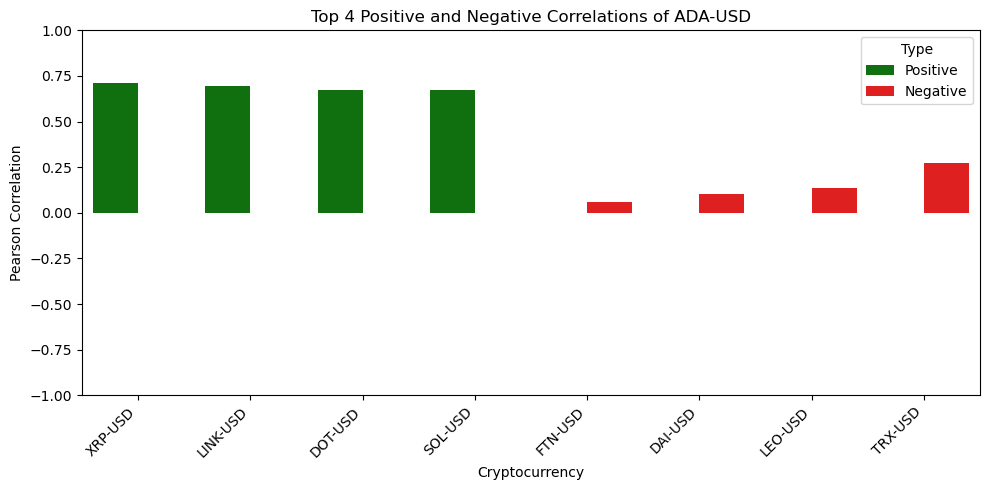

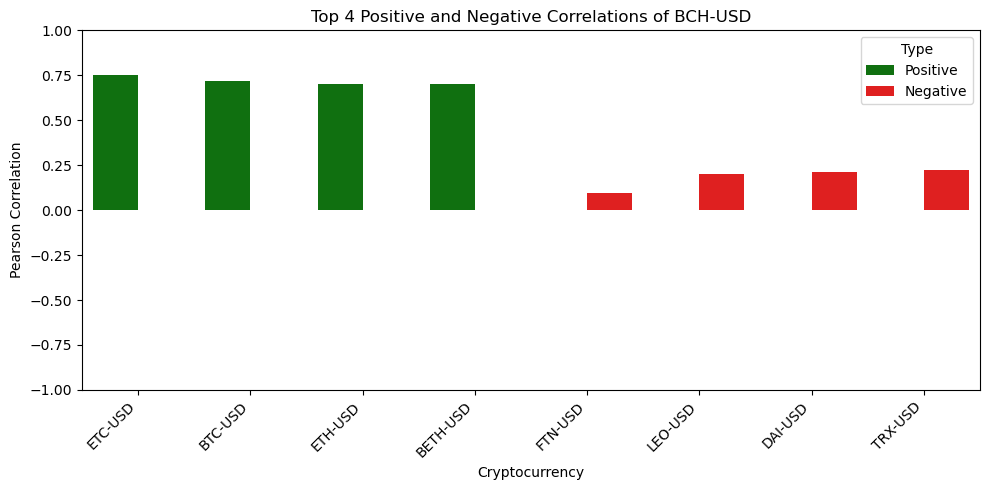

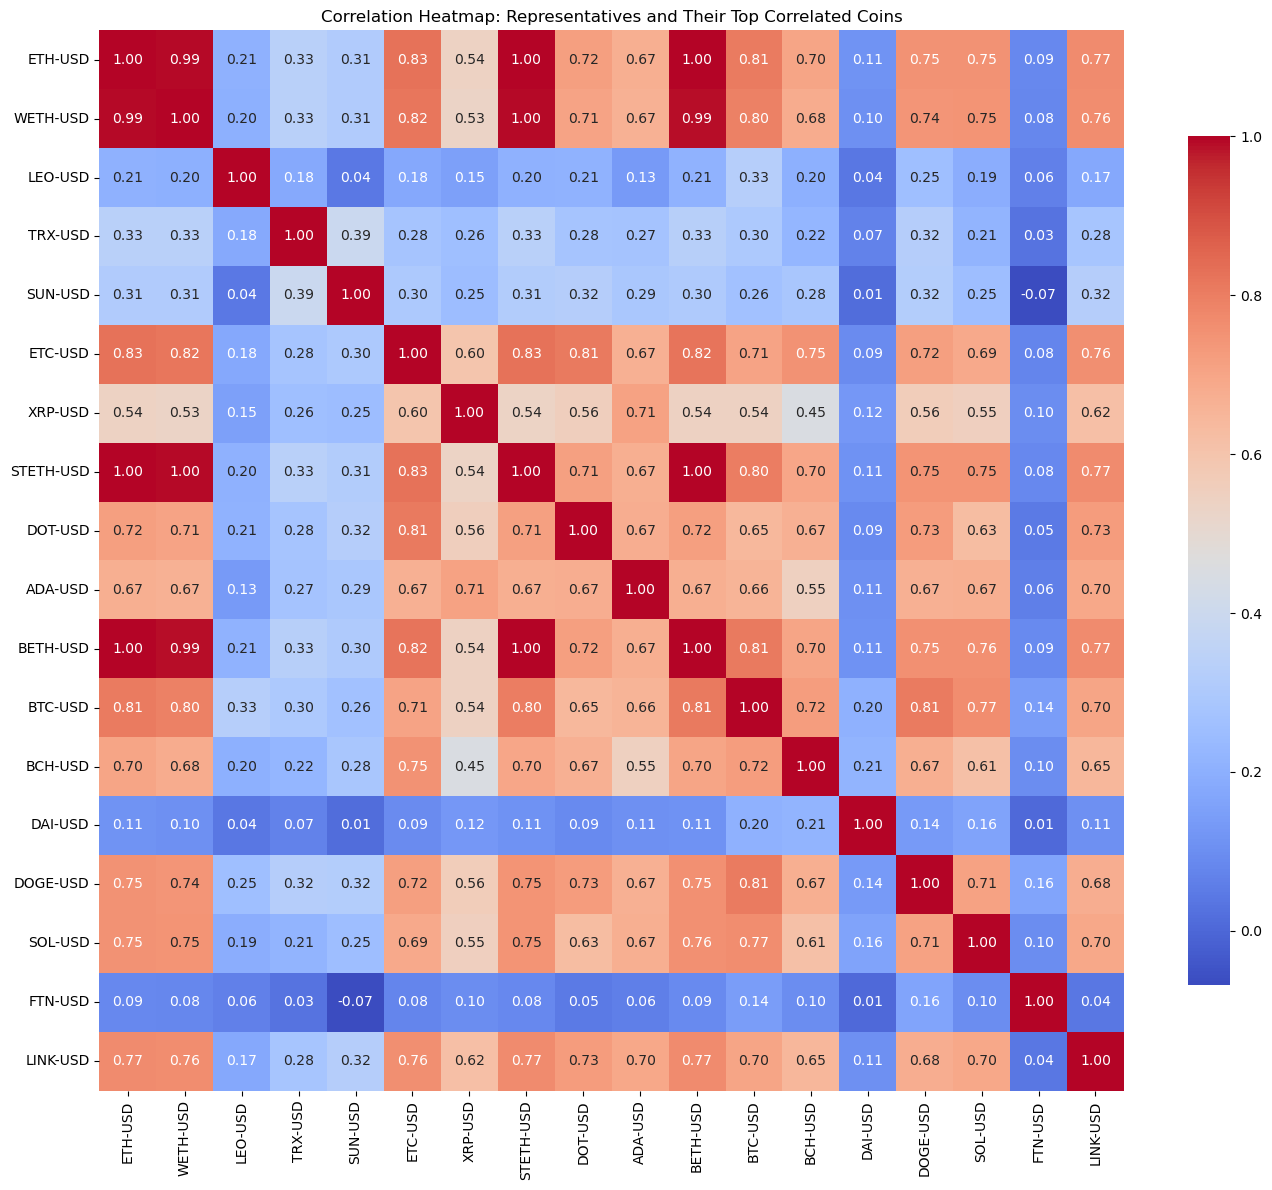

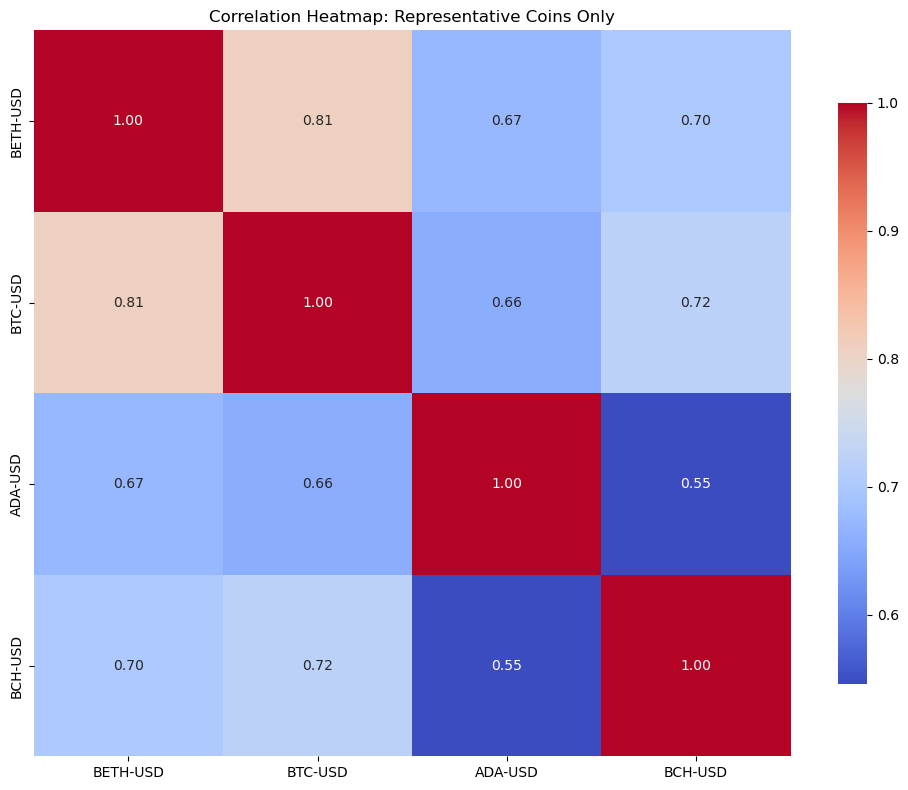

In [41]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directory for saving correlation results
output_dir = '../../results/Correlation_Results'
os.makedirs(output_dir, exist_ok=True)  # Create folder if missing

# Load cleaned cryptocurrency price data
prices = pd.read_csv('../../data/cleaned/crypto_dataset_cleaned.csv')
prices['Date'] = pd.to_datetime(prices['Date'])
prices.set_index('Date', inplace=True)

# Load updated representative coins list
rep_coins_df = pd.read_csv('../../data/processed/representative_coins.csv')
representatives = rep_coins_df['Representative_Coin'].tolist()

# Select 4 representative cryptocurrencies (customize if needed)
selected_coins = representatives[:4]  # e.g. ['BETH-USD', 'BTC-USD', 'ADA-USD', 'BCH-USD']

# Calculate daily returns for entire dataset
returns = prices.pct_change().dropna()

# Calculate full correlation matrix of all coins
corr_matrix = returns.corr()

# Save full correlation matrix
corr_matrix.to_csv(os.path.join(output_dir, "correlation_matrix_all.csv"))
print(f"Saved full correlation matrix to {os.path.join(output_dir, 'correlation_matrix_all.csv')}")

# Function to get top 4 positive and negative correlations for each selected coin
def get_top_correlations(corr_mat, selected, top_n=4):
    results = {}
    for coin in selected:
        coin_corr = corr_mat[coin].drop(labels=[coin])
        top_pos = coin_corr.sort_values(ascending=False).head(top_n)
        top_neg = coin_corr.sort_values(ascending=True).head(top_n)
        results[coin] = {'Positive': top_pos, 'Negative': top_neg}
    return results

top_corrs = get_top_correlations(corr_matrix, selected_coins)

# Prepare tidy DataFrame of top correlations and save
rows = []
for rep_coin, corr_data in top_corrs.items():
    for coin, val in corr_data['Positive'].items():
        rows.append({'Representative': rep_coin, 'Coin': coin, 'Correlation': val, 'Type': 'Positive'})
    for coin, val in corr_data['Negative'].items():
        rows.append({'Representative': rep_coin, 'Coin': coin, 'Correlation': val, 'Type': 'Negative'})

top_corr_df = pd.DataFrame(rows)
top_corr_path = os.path.join(output_dir, "top_correlations.csv")
top_corr_df.to_csv(top_corr_path, index=False)
print(f"Saved top correlations table to {top_corr_path}")

# Calculate correlation matrix for representatives only and save
rep_returns = returns[selected_coins]
rep_corr_matrix = rep_returns.corr()
rep_corr_path = os.path.join(output_dir, "representative_correlation_matrix.csv")
rep_corr_matrix.to_csv(rep_corr_path)
print(f"Saved representative correlation matrix to {rep_corr_path}")

# Print textual summary
print("\nCryptocurrency Correlation Analysis for Representative Coins\n")
for coin in selected_coins:
    print(f"--- {coin} ---")
    print("Top 4 Positive Correlations:")
    for c, val in top_corrs[coin]['Positive'].items():
        print(f"  {c}: {val:.3f}")
    print("Top 4 Negative Correlations:")
    for c, val in top_corrs[coin]['Negative'].items():
        print(f"  {c}: {val:.3f}")
    print()

# Plot grouped bar charts for top correlations per coin
def plot_assessment_top_correlations(top_corrs):
    for coin in top_corrs:
        pos_corr = top_corrs[coin]['Positive']
        neg_corr = top_corrs[coin]['Negative']

        plot_df = pd.DataFrame({
            'Correlation': np.concatenate([pos_corr.values, neg_corr.values]),
            'Coin': list(pos_corr.index) + list(neg_corr.index),
            'Type': ['Positive'] * len(pos_corr) + ['Negative'] * len(neg_corr)
        })

        plt.figure(figsize=(10, 5))
        sns.barplot(
            x='Coin',
            y='Correlation',
            hue='Type',
            data=plot_df,
            palette={'Positive': 'green', 'Negative': 'red'},
            dodge=True
        )
        plt.title(f"Top 4 Positive and Negative Correlations of {coin}")
        plt.ylim(-1, 1)
        plt.ylabel('Pearson Correlation')
        plt.xlabel('Cryptocurrency')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Type')
        plt.tight_layout()
        plt.show()

plot_assessment_top_correlations(top_corrs)

# Plot heatmap of representatives and their top correlated coins
heatmap_coins = set(selected_coins)
for corr_data in top_corrs.values():
    heatmap_coins.update(corr_data['Positive'].index)
    heatmap_coins.update(corr_data['Negative'].index)

heatmap_coins_filtered = [c for c in heatmap_coins if c in returns.columns]
heatmap_returns = returns[heatmap_coins_filtered]
heatmap_corr = heatmap_returns.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(heatmap_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Representatives and Their Top Correlated Coins')
plt.tight_layout()
plt.show()

# Plot heatmap for only representatives
plt.figure(figsize=(10, 8))
sns.heatmap(rep_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={"shrink":0.8})
plt.title('Correlation Heatmap: Representative Coins Only')
plt.tight_layout()
plt.show()
